In [1]:
# =============================================================================
# IMPORTS Y CONFIGURACIÓN
# =============================================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json
import gc
import psutil
import os
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración para plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 7)

# Paths
OUTPUT_DIR = "../data/process/"
sentences_path = f"{OUTPUT_DIR}sentences_final.parquet"
entities_path = f"{OUTPUT_DIR}entities.parquet"
main_path = f"{OUTPUT_DIR}main_cleaned.parquet"
REPORT_DIR = Path("../reports/eda/")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("EDA COMPLETO Y MEJORADO - DATASET NER")
print("="*80)

EDA COMPLETO Y MEJORADO - DATASET NER


In [2]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def save_report(data, filename, format='json'):
    """Guarda reportes en formato JSON o CSV"""
    filepath = REPORT_DIR / filename
    if format == 'json':
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    elif format == 'csv' and isinstance(data, (pl.DataFrame, pd.DataFrame)):
        if isinstance(data, pl.DataFrame):
            data.write_csv(filepath)
        else:
            data.to_csv(filepath, index=False)
    print(f"✓ Reporte guardado: {filepath}")

def plot_and_save(fig, filename):
    """Guarda figura y la muestra"""
    filepath = REPORT_DIR / filename
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfico guardado: {filepath}")
    plt.show()

def calculate_gini(counts):
    """Calcula el coeficiente de Gini para medir desbalance"""
    sorted_counts = np.sort(counts)
    n = len(counts)
    cumsum = np.cumsum(sorted_counts)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n

def print_section(title):
    """Imprime encabezado de sección"""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)

def liberar_ram():
    """Libera RAM y muestra uso actual"""
    process = psutil.Process(os.getpid())
    mem_antes = process.memory_info().rss / 1024 / 1024  # MB
    
    # Colectar garbage
    gc.collect()
    
    mem_despues = process.memory_info().rss / 1024 / 1024
    print(f"RAM liberada: {mem_antes - mem_despues:.2f} MB")
    print(f"RAM actual: {mem_despues:.2f} MB")


In [3]:
# =============================================================================
# CARGA DE DATOS (usando 1/2.5 de los datos)
# =============================================================================
print_section("CARGA DE DATOS (1/2.5 de los datos)")

# Cargar los datos completos
main_df_full = pl.read_parquet(main_path)
entities_df_full = pl.read_parquet(entities_path)
sentences_df_full = pl.scan_parquet(sentences_path).select([
    "sentence_id", 
    "sentence",
    pl.col("sentence").str.len_chars().alias("sentence_length_chars"),
    pl.col("tokens").list.len().alias("num_tokens")
]).collect()

# Seleccionar 1/2.5 de los datos de manera reproducible
seed = 42
n_main = main_df_full.height

# Sample sobre main, luego filtrar sentences y join entities
main_df = main_df_full.sample(n=int(n_main/2.5), seed=seed)
sentence_ids_sample = main_df["sentence_id"].unique()
sentences_df = sentences_df_full.filter(pl.col("sentence_id").is_in(sentence_ids_sample))
entities_df = entities_df_full  # NO dividir entidades

print(f"✓ Main (anotaciones, 1/2.5): {main_df.shape}")
print(f"✓ Entities (completo): {entities_df.shape}")
print(f"✓ Sentences (1/2.5): {sentences_df.shape}")

# Join ligero
entities_light = entities_df.select(["entity_id", "entity", "type_entity", "iob_tag"])
main_with_entities = main_df.join(entities_light, on="entity_id", how="left")

# Features derivadas
main_with_entities = main_with_entities.with_columns([
    (pl.col("char_end") - pl.col("char_start")).alias("entity_length_chars"),
    (pl.col("token_end") - pl.col("token_start") + 1).alias("entity_length_tokens"),
])

sentences_with_annots = main_with_entities.group_by("sentence_id").agg([
    pl.count().alias("num_entities"),
    pl.col("entity_length_chars").mean().alias("avg_entity_length"),
    pl.col("entity_length_chars").max().alias("max_entity_length")
]).join(sentences_df, on="sentence_id", how="left")

print(f"✓ Main + Entities (1/2.5): {main_with_entities.shape}")


CARGA DE DATOS (1/2.5 de los datos)


✓ Main (anotaciones, 1/2.5): (10918430, 7)
✓ Entities (completo): (695252, 4)
✓ Sentences (1/2.5): (3178926, 4)
✓ Main + Entities (1/2.5): (10918430, 12)


In [4]:
# =============================================================================
# SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES
# =============================================================================
print_section("SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES")

quality_report = {}

# 1.1 Valores nulos
print("\n--- Valores Nulos ---")
null_counts = main_with_entities.null_count()
print(null_counts)
quality_report['null_counts'] = {col: int(null_counts[col][0]) for col in null_counts.columns}

# 1.2 Duplicados
print("\n--- Duplicados ---")
duplicates = main_with_entities.filter(
    pl.struct(["sentence_id", "char_start", "char_end", "entity"]).is_duplicated()
)
print(f"Anotaciones duplicadas: {len(duplicates)} ({100*len(duplicates)/len(main_with_entities):.2f}%)")
quality_report['duplicates'] = len(duplicates)

if len(duplicates) > 0:
    print("\nEjemplos de duplicados (top 5):")
    print(duplicates.head(5).select(["sentence_id", "entity", "type_entity", "char_start", "char_end"]))

# 1.3 Inconsistencias: misma entidad, diferentes tipos
print("\n--- Inconsistencias de Tipos ---")
entity_type_conflicts = entities_df.group_by("entity").agg([
    pl.col("type_entity").n_unique().alias("num_types"),
    pl.col("type_entity").alias("types")
]).filter(pl.col("num_types") > 1).sort("num_types", descending=True)

print(f"Entidades con múltiples tipos: {len(entity_type_conflicts)}")
quality_report['ambiguous_entities'] = len(entity_type_conflicts)

if len(entity_type_conflicts) > 0:
    print("\nTop 10 entidades ambiguas:")
    print(entity_type_conflicts.head(10))
    save_report(entity_type_conflicts.to_pandas(), 'ambiguous_entities.csv', 'csv')



SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES

--- Valores Nulos ---
shape: (1, 12)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬─────────┬───────────┬───────────┐
│ entity_loc ┆ sentence_ ┆ entity_id ┆ char_star ┆ … ┆ type_enti ┆ iob_tag ┆ entity_le ┆ entity_le │
│ al_id      ┆ id        ┆ ---       ┆ t         ┆   ┆ ty        ┆ ---     ┆ ngth_char ┆ ngth_toke │
│ ---        ┆ ---       ┆ u32       ┆ ---       ┆   ┆ ---       ┆ u32     ┆ s         ┆ ns        │
│ u32        ┆ u32       ┆           ┆ u32       ┆   ┆ u32       ┆         ┆ ---       ┆ ---       │
│            ┆           ┆           ┆           ┆   ┆           ┆         ┆ u32       ┆ u32       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═════════╪═══════════╪═══════════╡
│ 0          ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0       ┆ 0         ┆ 0         │
└────────────┴───────────┴───────────┴───────────┴───┴───────────┴─────────┴───────────┴───────────┘

--- Dupl

Anotaciones duplicadas: 172681 (1.58%)

Ejemplos de duplicados (top 5):
shape: (5, 5)
┌──────────────┬─────────────┬─────────────┬────────────┬──────────┐
│ sentence_id  ┆ entity      ┆ type_entity ┆ char_start ┆ char_end │
│ ---          ┆ ---         ┆ ---         ┆ ---        ┆ ---      │
│ str          ┆ str         ┆ str         ┆ i64        ┆ i64      │
╞══════════════╪═════════════╪═════════════╪════════════╪══════════╡
│ SENT_1561737 ┆ pepper      ┆ FOOD        ┆ 163        ┆ 169      │
│ SENT_828849  ┆ Ingredients ┆ FOOD        ┆ 0          ┆ 11       │
│ SENT_873634  ┆ pepper      ┆ FOOD        ┆ 33         ┆ 39       │
│ SENT_886492  ┆ tomato      ┆ FOOD        ┆ 16         ┆ 22       │
│ SENT_1814275 ┆ butter      ┆ FOOD        ┆ 8          ┆ 14       │
└──────────────┴─────────────┴─────────────┴────────────┴──────────┘

--- Inconsistencias de Tipos ---
Entidades con múltiples tipos: 329

Top 10 entidades ambiguas:
shape: (10, 3)
┌─────────────────┬───────────┬────────────

In [5]:

# 1.4 Overlaps: anotaciones solapadas
print("\n--- Overlaps (Anotaciones Solapadas) ---")
overlaps = main_df.sort(["sentence_id", "char_start"]).with_columns([
    pl.col("char_end").shift(1).over("sentence_id").alias("prev_end"),
    pl.col("sentence_id").shift(1).alias("prev_sent"),
    pl.col("entity_id").shift(1).over("sentence_id").alias("prev_entity_id")
]).filter(
    (pl.col("sentence_id") == pl.col("prev_sent")) & 
    (pl.col("char_start") < pl.col("prev_end"))
)

print(f"Anotaciones con overlap: {len(overlaps)} ({100*len(overlaps)/len(main_df):.2f}%)")
quality_report['overlaps'] = len(overlaps)

if len(overlaps) > 0:
    print("\nEjemplos de overlaps (top 5):")
    print(overlaps.head(5).select(["sentence_id", "entity_id", "prev_entity_id", "char_start", "char_end", "prev_end"]))

# 1.5 Posiciones inválidas
print("\n--- Posiciones Inválidas ---")
invalid_positions = main_df.join(
    sentences_df.select(["sentence_id", "num_tokens"]), 
    on="sentence_id"
).filter(pl.col("token_end") >= pl.col("num_tokens"))

print(f"Anotaciones fuera de rango de tokens: {len(invalid_positions)}")
quality_report['invalid_positions'] = len(invalid_positions)

# 1.6 Validación de longitudes (negativos, ceros)
invalid_lengths = main_with_entities.filter(
    (pl.col("entity_length_chars") <= 0) | 
    (pl.col("entity_length_tokens") <= 0)
)
print(f"Entidades con longitud inválida: {len(invalid_lengths)}")
quality_report['invalid_lengths'] = len(invalid_lengths)

# Guardar reporte de calidad
save_report(quality_report, 'quality_report.json')


--- Overlaps (Anotaciones Solapadas) ---
Anotaciones con overlap: 156922 (1.44%)

Ejemplos de overlaps (top 5):
shape: (5, 6)
┌─────────────┬────────────┬────────────────┬────────────┬──────────┬──────────┐
│ sentence_id ┆ entity_id  ┆ prev_entity_id ┆ char_start ┆ char_end ┆ prev_end │
│ ---         ┆ ---        ┆ ---            ┆ ---        ┆ ---      ┆ ---      │
│ str         ┆ str        ┆ str            ┆ i64        ┆ i64      ┆ i64      │
╞═════════════╪════════════╪════════════════╪════════════╪══════════╪══════════╡
│ SENT_00002  ┆ UENT_00084 ┆ UENT_00048     ┆ 49         ┆ 55       ┆ 55       │
│ SENT_00075  ┆ UENT_00002 ┆ UENT_00895     ┆ 64         ┆ 68       ┆ 68       │
│ SENT_00145  ┆ UENT_00038 ┆ UENT_00028     ┆ 236        ┆ 242      ┆ 242      │
│ SENT_00216  ┆ UENT_00347 ┆ UENT_01043     ┆ 9          ┆ 13       ┆ 13       │
│ SENT_00242  ┆ UENT_00309 ┆ UENT_00008     ┆ 8          ┆ 23       ┆ 15       │
└─────────────┴────────────┴────────────────┴────────────┴─────

In [6]:
# =============================================================================
# SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB
# =============================================================================
print_section("SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB")

iob_report = {}

# 2.1 Consistencia de secuencias IOB
print("\n--- Validación de Secuencias IOB ---")
iob_validation = main_with_entities.sort(["sentence_id", "token_start"]).with_columns([
    pl.col("iob_tag").shift(1).over("sentence_id").alias("prev_iob"),
    pl.col("type_entity").shift(1).over("sentence_id").alias("prev_type")
])

# I- debe seguir a B- o I- del mismo tipo
invalid_iob = iob_validation.filter(
    (pl.col("iob_tag").str.contains("^I-")) &
    (
        (~pl.col("prev_iob").str.contains("^[BI]-")) |
        (pl.col("type_entity") != pl.col("prev_type"))
    )
)

print(f"Secuencias IOB inválidas: {len(invalid_iob)} ({100*len(invalid_iob)/len(main_with_entities):.2f}%)")
iob_report['invalid_sequences'] = len(invalid_iob)

if len(invalid_iob) > 0:
    print("\nEjemplos de secuencias inválidas (top 5):")
    print(invalid_iob.head(5).select(["sentence_id", "entity", "type_entity", "iob_tag", "prev_iob", "prev_type"]))

# 2.2 Longitud de secuencias (cuántos tokens por entidad)
print("\n--- Longitud de Secuencias IOB ---")

# Método más robusto para calcular longitud de secuencias
sequence_lengths = main_with_entities.sort(["sentence_id", "token_start"]).with_columns([
    # Identificar inicio de nuevas entidades
    pl.when(pl.col("iob_tag").str.starts_with("B-"))
      .then(1)
      .when(pl.col("iob_tag") == "O")
      .then(0)
      .when(
          (pl.col("iob_tag").str.starts_with("I-")) & 
          (pl.col("iob_tag").shift(1).over("sentence_id").str.starts_with("B-") |
           pl.col("iob_tag").shift(1).over("sentence_id").str.starts_with("I-"))
      )
      .then(0)
      .otherwise(1)
      .alias("new_entity_flag")
]).with_columns([
    # Crear ID único para cada secuencia de entidad
    pl.col("new_entity_flag").cum_sum().over("sentence_id").alias("entity_seq_id")
]).filter(
    # Filtrar solo tokens que son parte de entidades (no 'O')
    pl.col("iob_tag") != "O"
).group_by(["sentence_id", "entity_seq_id"]).agg([
    pl.count().alias("seq_length"),
    pl.col("type_entity").first().alias("type_entity")
])

# Si no hay secuencias, crear un DataFrame vacío con la estructura esperada
if len(sequence_lengths) == 0:
    sequence_lengths = pl.DataFrame({
        "sentence_id": [],
        "entity_seq_id": [],
        "seq_length": [],
        "type_entity": []
    })

# Calcular estadísticas
if len(sequence_lengths) > 0:
    # Convertir a pandas para usar describe() y obtener los nombres de columna correctos
    seq_lengths_pd = sequence_lengths.to_pandas()
    seq_stats = seq_lengths_pd["seq_length"].describe()
    print("Estadísticas de longitud de secuencias IOB:")
    print(seq_stats)
    
    # Longitud de secuencias por tipo
    seq_by_type = sequence_lengths.group_by("type_entity").agg([
        pl.col("seq_length").mean().alias("avg_seq_length"),
        pl.col("seq_length").max().alias("max_seq_length"),
        pl.count().alias("num_sequences")
    ]).sort("avg_seq_length", descending=True)

    print("\nLongitud de secuencias por tipo (top 10):")
    print(seq_by_type.head(10))

    iob_report['sequence_stats'] = {
        'mean': float(seq_stats["mean"]),
        'max': float(seq_stats["max"]),
        'total_sequences': int(seq_stats["count"])
    }
else:
    print("No se encontraron secuencias de entidades para analizar.")
    iob_report['sequence_stats'] = {
        'mean': 0,
        'max': 0,
        'total_sequences': 0
    }

save_report(iob_report, 'iob_validation_report.json')


SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB

--- Validación de Secuencias IOB ---
Secuencias IOB inválidas: 0 (0.00%)

--- Longitud de Secuencias IOB ---
Estadísticas de longitud de secuencias IOB:
count    10918430.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0
Name: seq_length, dtype: float64

Longitud de secuencias por tipo (top 10):
shape: (9, 4)
┌──────────────────┬────────────────┬────────────────┬───────────────┐
│ type_entity      ┆ avg_seq_length ┆ max_seq_length ┆ num_sequences │
│ ---              ┆ ---            ┆ ---            ┆ ---           │
│ str              ┆ f64            ┆ u32            ┆ u32           │
╞══════════════════╪════════════════╪════════════════╪═══════════════╡
│ PART             ┆ 1.0            ┆ 1              ┆ 25            │
│ FOOD             ┆ 1.0            ┆ 1              ┆ 10914716      │
│ PROCESS          ┆ 1.0            ┆ 1              ┆ 486

In [7]:
# =============================================================================
# SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
# =============================================================================
print_section("SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA")
liberar_ram()
basic_stats = {}

# Totales
total_annots = len(main_with_entities)
unique_entities = main_with_entities['entity_id'].n_unique()
unique_sentences = main_with_entities['sentence_id'].n_unique()

print(f"Total anotaciones: {total_annots:,}")
print(f"Entidades únicas: {unique_entities:,}")
print(f"Oraciones con anotaciones: {unique_sentences:,}")

basic_stats['total_annotations'] = total_annots
basic_stats['unique_entities'] = unique_entities
basic_stats['annotated_sentences'] = unique_sentences

# Cobertura
total_sentences = len(sentences_df)
coverage = 100 * unique_sentences / total_sentences
print(f"\nCobertura: {coverage:.1f}% ({unique_sentences:,} / {total_sentences:,} oraciones)")
basic_stats['coverage_pct'] = float(coverage)

# Entidades por oración
annots_per_sent = sentences_with_annots["num_entities"].describe()
print("\nEntidades por oración:")
print(annots_per_sent)

# Análisis de percentiles detallado
print("\n--- Análisis de Percentiles (Entidades por Oración) ---")
num_entities_arr = sentences_with_annots["num_entities"].to_numpy()
percentiles = [50, 75, 90, 95, 97.5, 99, 99.5, 99.9, 100]
percentile_values = {p: np.percentile(num_entities_arr, p) for p in percentiles}

for p in percentiles:
    p_value = percentile_values[p]
    sents_above = sentences_with_annots.filter(pl.col("num_entities") > p_value)
    print(f"P{p}: {p_value:.1f} entidades | {len(sents_above)} oraciones sobre este umbral")

# Identificar oraciones extremas
extreme_sentences = sentences_with_annots.filter(pl.col("num_entities") > percentile_values[99]).sort("num_entities", descending=True)
print(f"\nOraciones en top 1% (>{percentile_values[99]:.0f} entidades): {len(extreme_sentences)}")
print("\nTop 10 oraciones con más entidades:")
print(extreme_sentences.head(10).select(["sentence_id", "num_entities", "sentence_length_chars"]))

save_report(basic_stats, 'basic_stats.json')


SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
RAM liberada: 0.00 MB
RAM actual: 16680.01 MB
Total anotaciones: 10,918,430
Entidades únicas: 417,115
Oraciones con anotaciones: 3,178,926

Cobertura: 100.0% (3,178,926 / 3,178,926 oraciones)

Entidades por oración:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 3.178926e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 3.434629   │
│ std        ┆ 2.075927   │
│ min        ┆ 1.0        │
│ 25%        ┆ 2.0        │
│ 50%        ┆ 3.0        │
│ 75%        ┆ 4.0        │
│ max        ┆ 171.0      │
└────────────┴────────────┘

--- Análisis de Percentiles (Entidades por Oración) ---
P50: 3.0 entidades | 1307490 oraciones sobre este umbral
P75: 4.0 entidades | 793829 oraciones sobre este umbral
P90: 6.0 entidades | 248238 oraciones sobre este umbral
P95: 7.0 entidades | 134813 oraciones sobre este umbral
P97.5: 8.0 entidades | 


SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y DESBALANCE
RAM liberada: 0.00 MB
RAM actual: 16771.14 MB
Distribución de tipos de entidades:
shape: (9, 2)
┌──────────────────┬──────────┐
│ type_entity      ┆ count    │
│ ---              ┆ ---      │
│ str              ┆ u32      │
╞══════════════════╪══════════╡
│ FOOD             ┆ 10914716 │
│ QUANTITY         ┆ 1466     │
│ UNIT             ┆ 1263     │
│ PROCESS          ┆ 486      │
│ PHYSICAL_QUALITY ┆ 294      │
│ COLOR            ┆ 80       │
│ PURPOSE          ┆ 56       │
│ TASTE            ┆ 44       │
│ PART             ┆ 25       │
└──────────────────┴──────────┘

--- Métricas de Desbalance ---
Coeficiente de Gini: 0.889 (0=balance perfecto, 1=máximo desbalance)
Entropía: 0.004 (mayor=más uniforme)
Ratio max/min: 436588.6x

Tipos raros (<1% = 109184 anotaciones): 8
shape: (8, 2)
┌──────────────────┬───────┐
│ type_entity      ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ QUANTITY  

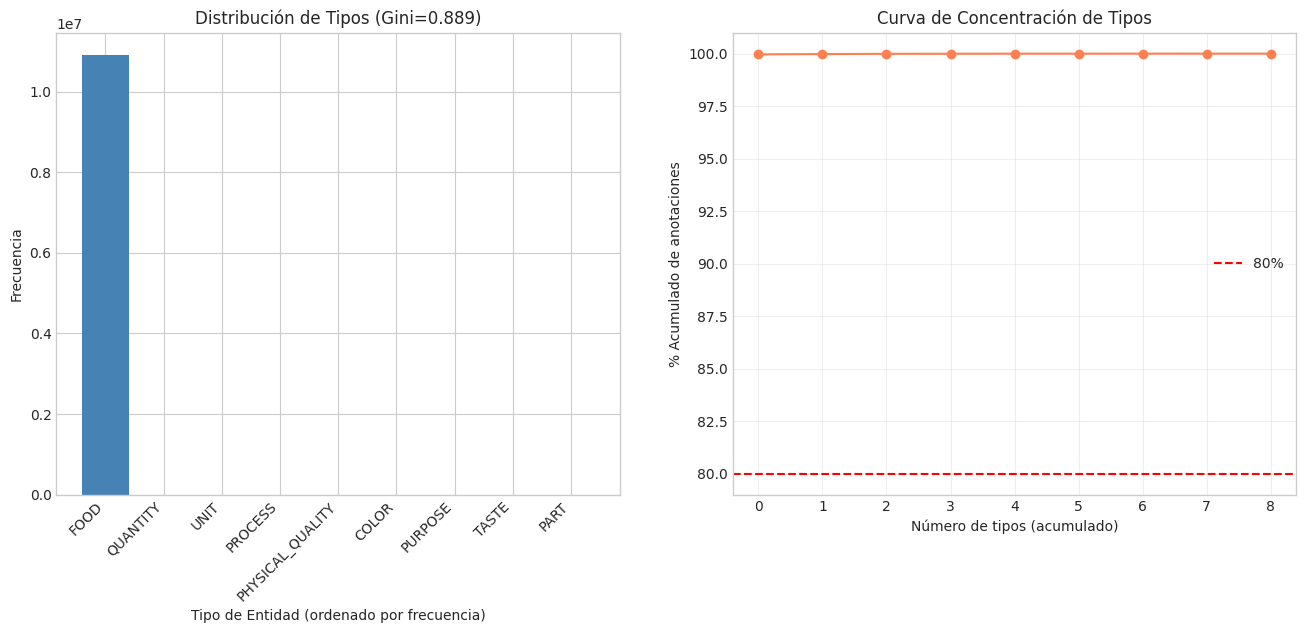

✓ Reporte guardado: ../reports/eda/type_stats.json


In [8]:
# =============================================================================
# SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y ANÁLISIS DE DESBALANCE
# =============================================================================
print_section("SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y DESBALANCE")
liberar_ram()

type_stats = {}

# Distribución de tipos
type_dist = main_with_entities["type_entity"].value_counts().sort("count", descending=True)
print("Distribución de tipos de entidades:")
print(type_dist)

# Métricas de desbalance
type_counts = type_dist["count"].to_numpy()
gini = calculate_gini(type_counts)
ent = entropy(type_counts / type_counts.sum())
max_ratio = type_counts.max() / type_counts.min()

print(f"\n--- Métricas de Desbalance ---")
print(f"Coeficiente de Gini: {gini:.3f} (0=balance perfecto, 1=máximo desbalance)")
print(f"Entropía: {ent:.3f} (mayor=más uniforme)")
print(f"Ratio max/min: {max_ratio:.1f}x")

type_stats['gini_coefficient'] = float(gini)
type_stats['entropy'] = float(ent)
type_stats['max_min_ratio'] = float(max_ratio)
type_stats['num_types'] = len(type_dist)

# Tipos raros (< 1% del total)
rare_threshold = 0.01 * total_annots
rare_types = type_dist.filter(pl.col("count") < rare_threshold)
print(f"\nTipos raros (<1% = {rare_threshold:.0f} anotaciones): {len(rare_types)}")
if len(rare_types) > 0:
    print(rare_types)
type_stats['rare_types_count'] = len(rare_types)

# Distribución IOB
iob_dist = main_with_entities["iob_tag"].value_counts().sort("count", descending=True)
print("\nDistribución de IOB tags (top 15):")
print(iob_dist.head(15))

# Plot distribución de tipos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_dist_pd = type_dist.to_pandas()
axes[0].bar(range(len(type_dist_pd)), type_dist_pd["count"], color='steelblue')
axes[0].set_xlabel("Tipo de Entidad (ordenado por frecuencia)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title(f"Distribución de Tipos (Gini={gini:.3f})")
axes[0].set_xticks(range(len(type_dist_pd)))
axes[0].set_xticklabels(type_dist_pd["type_entity"], rotation=45, ha='right')

# Acumulado
cumsum = np.cumsum(type_dist_pd["count"]) / type_dist_pd["count"].sum() * 100
axes[1].plot(range(len(cumsum)), cumsum, marker='o', color='coral')
axes[1].axhline(80, color='red', linestyle='--', label='80%')
axes[1].set_xlabel("Número de tipos (acumulado)")
axes[1].set_ylabel("% Acumulado de anotaciones")
axes[1].set_title("Curva de Concentración de Tipos")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plot_and_save(fig, 'type_distribution.png')

save_report(type_stats, 'type_stats.json')


SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
RAM liberada: 0.00 MB
RAM actual: 16825.14 MB
Estadísticas de longitud de entidades (chars):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.091843e7 │
│ null_count ┆ 0.0        │
│ mean       ┆ 8.179103   │
│ std        ┆ 4.741525   │
│ min        ┆ 0.0        │
│ 25%        ┆ 5.0        │
│ 50%        ┆ 7.0        │
│ 75%        ┆ 11.0       │
│ max        ┆ 135.0      │
└────────────┴────────────┘

Longitud de entidades por tipo:
shape: (9, 7)
┌──────────────────┬─────────────┬───────────────┬────────────┬────────────┬────────────┬──────────┐
│ type_entity      ┆ mean_length ┆ median_length ┆ std_length ┆ min_length ┆ max_length ┆ count    │
│ ---              ┆ ---         ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---      │
│ str              ┆ f64         ┆ f64           ┆ f64      

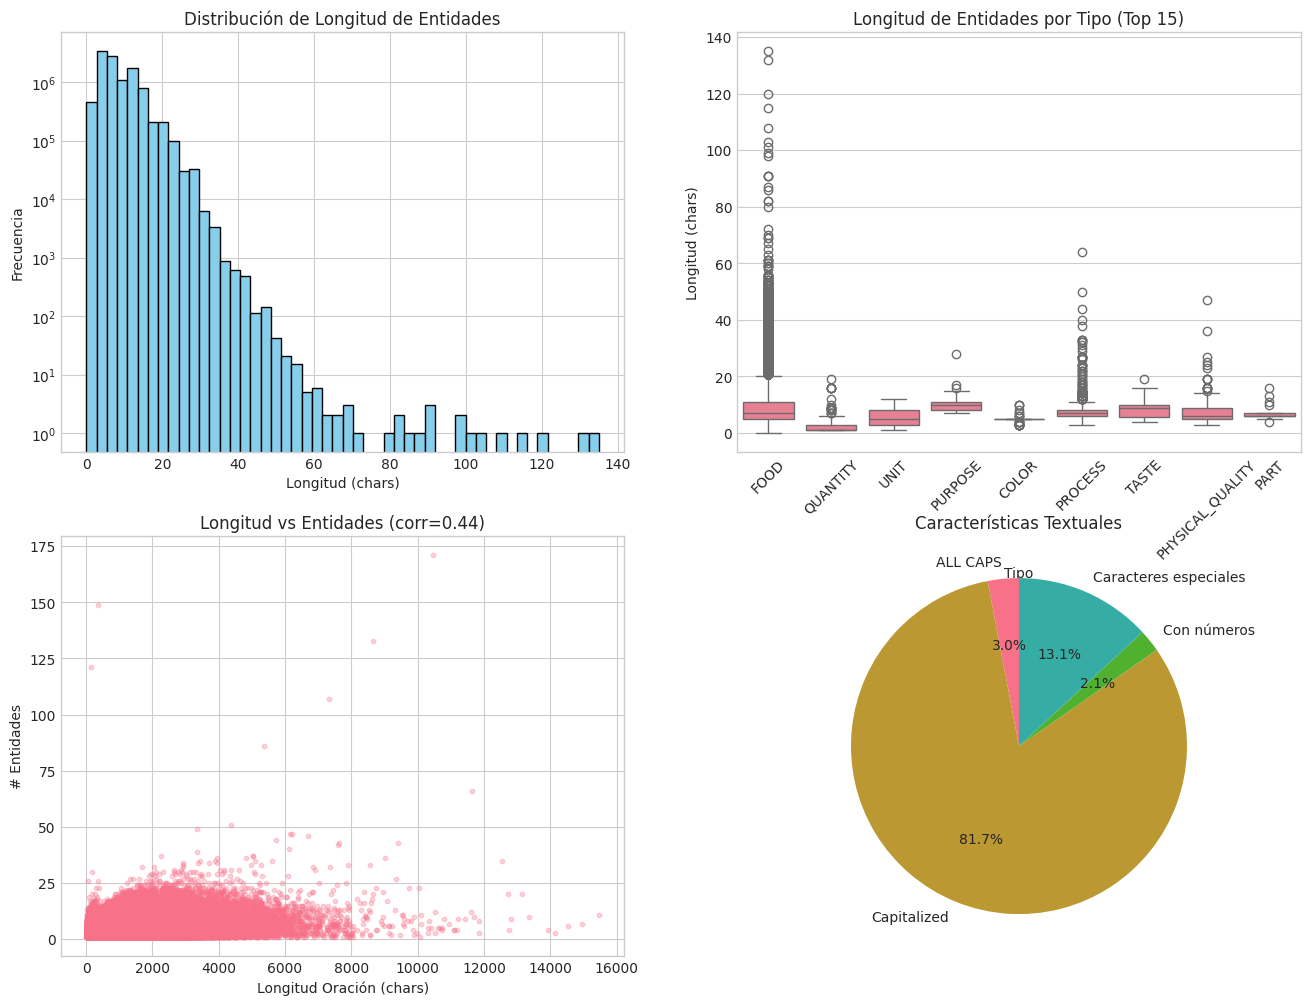

✓ Reporte guardado: ../reports/eda/text_analysis.json


In [9]:
# =============================================================================
# SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
# =============================================================================
print_section("SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES")
liberar_ram()

text_analysis = {}

# Estadísticas de longitud de entidades
length_stats = main_with_entities["entity_length_chars"].describe()
print("Estadísticas de longitud de entidades (chars):")
print(length_stats)

# Longitudes por tipo
length_by_type = main_with_entities.group_by("type_entity").agg([
    pl.col("entity_length_chars").mean().alias("mean_length"),
    pl.col("entity_length_chars").median().alias("median_length"),
    pl.col("entity_length_chars").std().alias("std_length"),
    pl.col("entity_length_chars").min().alias("min_length"),
    pl.col("entity_length_chars").max().alias("max_length"),
    pl.count().alias("count")
]).sort("mean_length", descending=True)

print("\nLongitud de entidades por tipo:")
print(length_by_type)

# Tipos con mayor variabilidad
print("\nTipos con mayor variabilidad en longitud (top 5):")
print(length_by_type.sort("std_length", descending=True).head(5))

# Análisis de características textuales
print("\n--- Características Textuales ---")
main_with_entities = main_with_entities.with_columns([
    pl.col("entity").str.to_uppercase().alias("entity_upper"),
    (pl.col("entity") == pl.col("entity").str.to_uppercase()).alias("is_all_caps"),
    (pl.col("entity").str.slice(0, 1) == pl.col("entity").str.slice(0, 1).str.to_uppercase()).alias("is_capitalized"),
    pl.col("entity").str.contains(r"\d").alias("has_numbers"),
    pl.col("entity").str.contains(r"[^a-zA-Z0-9\s]").alias("has_special_chars")
])

caps_stats = main_with_entities.select([
    pl.col("is_all_caps").sum().alias("all_caps"),
    pl.col("is_capitalized").sum().alias("capitalized"),
    pl.col("has_numbers").sum().alias("with_numbers"),
    pl.col("has_special_chars").sum().alias("with_special_chars")
])
print(caps_stats)

text_analysis['all_caps_pct'] = float(100 * caps_stats["all_caps"][0] / total_annots)
text_analysis['with_numbers_pct'] = float(100 * caps_stats["with_numbers"][0] / total_annots)

# Entidades muy cortas (posibles errores)
very_short = main_with_entities.filter(pl.col("entity_length_chars") <= 2)
print(f"\nEntidades muy cortas (≤2 chars): {len(very_short)} ({100*len(very_short)/total_annots:.2f}%)")
print("Ejemplos:")
print(very_short.head(10).select(["entity", "type_entity", "entity_length_chars"]))

# Entidades muy largas
very_long = main_with_entities.filter(pl.col("entity_length_chars") > 100)
print(f"\nEntidades muy largas (>100 chars): {len(very_long)}")
if len(very_long) > 0:
    print("Top 5 más largas:")
    print(very_long.sort("entity_length_chars", descending=True).head(5).select(["entity", "type_entity", "entity_length_chars"]))

# Correlación longitud oración vs # entidades
corr_length_annots = sentences_with_annots.select([
    pl.corr("sentence_length_chars", "num_entities").alias("corr")
]).item()
print(f"\nCorrelación longitud oración vs # entidades: {corr_length_annots:.3f}")
text_analysis['corr_sent_length_num_entities'] = float(corr_length_annots)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de longitudes de entidades (con escala log)
axes[0,0].hist(main_with_entities["entity_length_chars"].to_numpy(), bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel("Longitud (chars)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title("Distribución de Longitud de Entidades")
axes[0,0].set_yscale('log')

# Boxplot por tipo (top 15 tipos)
top_15_types = type_dist.head(15)["type_entity"].to_list()
data_top15 = main_with_entities.filter(pl.col("type_entity").is_in(top_15_types))
sns.boxplot(data=data_top15.to_pandas(), x="type_entity", y="entity_length_chars", ax=axes[0,1])
axes[0,1].set_xlabel("Tipo")
axes[0,1].set_ylabel("Longitud (chars)")
axes[0,1].set_title("Longitud de Entidades por Tipo (Top 15)")
axes[0,1].tick_params(axis='x', rotation=45)

# Scatter: longitud oración vs # entidades
scatter_data = sentences_with_annots.to_pandas()
axes[1,0].scatter(scatter_data["sentence_length_chars"], scatter_data["num_entities"], alpha=0.3, s=10)
axes[1,0].set_xlabel("Longitud Oración (chars)")
axes[1,0].set_ylabel("# Entidades")
axes[1,0].set_title(f"Longitud vs Entidades (corr={corr_length_annots:.2f})")

# Pie chart de características textuales
char_features = [
    caps_stats["all_caps"][0],
    caps_stats["capitalized"][0] - caps_stats["all_caps"][0],
    caps_stats["with_numbers"][0],
    caps_stats["with_special_chars"][0]
]
labels = ['ALL CAPS', 'Capitalized', 'Con números', 'Caracteres especiales']
axes[1,1].pie(char_features, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title("Características Textuales")

plot_and_save(fig, 'text_analysis.png')

save_report(text_analysis, 'text_analysis.json')

In [10]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS Y CONTEXTO
# =============================================================================
print_section("SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS")
liberar_ram()

cooccurrence_report = {}

# Co-ocurrencia de tipos en la misma oración
print("\n--- Co-ocurrencias de Tipos en Oraciones ---")
cooccurrence = main_with_entities.select(["sentence_id", "type_entity"]).join(
    main_with_entities.select(["sentence_id", "type_entity"]).rename({"type_entity": "other_type"}),
    on="sentence_id"
).filter(pl.col("type_entity") < pl.col("other_type"))  # Evitar duplicados (A-B == B-A)

cooccurrence_counts = cooccurrence.group_by(["type_entity", "other_type"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)

print("Top 20 pares de tipos que co-ocurren:")
print(cooccurrence_counts.head(20))

# Guardar top 50
save_report(cooccurrence_counts.head(50).to_pandas(), 'cooccurrences.csv', 'csv')

cooccurrence_report['total_cooccurrence_pairs'] = len(cooccurrence_counts)

# Posición en oración (inicio, medio, fin)
print("\n--- Posición de Entidades en Oración ---")
main_with_position = main_with_entities.join(
    sentences_df.select(["sentence_id", "sentence_length_chars"]),
    on="sentence_id"
).with_columns([
    (pl.col("char_start") / pl.col("sentence_length_chars")).alias("relative_pos")
]).with_columns([
    pl.when(pl.col("relative_pos") < 0.33).then(pl.lit("Inicio"))
    .when(pl.col("relative_pos") < 0.67).then(pl.lit("Medio"))
    .otherwise(pl.lit("Fin"))
    .alias("position_in_sent")
])

position_dist = main_with_position.group_by(["type_entity", "position_in_sent"]).agg(
    pl.count().alias("count")
)

print("Distribución de posiciones por tipo (top 10 tipos):")
top10_types = type_dist.head(10)["type_entity"].to_list()
print(position_dist.filter(pl.col("type_entity").is_in(top10_types)).sort(["type_entity", "position_in_sent"]))

# Entidades al inicio/fin absoluto
extreme_positions = main_with_position.filter(
    (pl.col("char_start") < 5) | (pl.col("char_end") > pl.col("sentence_length_chars") - 5)
)
print(f"\nEntidades en posiciones extremas (<5 chars del inicio/fin): {len(extreme_positions)}")

save_report(cooccurrence_report, 'cooccurrence_report.json')


SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS
RAM liberada: -78.48 MB
RAM actual: 18177.53 MB

--- Co-ocurrencias de Tipos en Oraciones ---
Top 20 pares de tipos que co-ocurren:
shape: (20, 3)
┌─────────────┬────────────┬───────┐
│ type_entity ┆ other_type ┆ count │
│ ---         ┆ ---        ┆ ---   │
│ str         ┆ str        ┆ u32   │
╞═════════════╪════════════╪═══════╡
│ FOOD        ┆ QUANTITY   ┆ 3556  │
│ FOOD        ┆ UNIT       ┆ 3176  │
│ QUANTITY    ┆ UNIT       ┆ 3027  │
│ FOOD        ┆ PROCESS    ┆ 1279  │
│ PROCESS     ┆ QUANTITY   ┆ 1120  │
│ …           ┆ …          ┆ …     │
│ FOOD        ┆ TASTE      ┆ 113   │
│ QUANTITY    ┆ TASTE      ┆ 94    │
│ PURPOSE     ┆ UNIT       ┆ 88    │
│ TASTE       ┆ UNIT       ┆ 82    │
│ PART        ┆ QUANTITY   ┆ 63    │
└─────────────┴────────────┴───────┘
✓ Reporte guardado: ../reports/eda/cooccurrences.csv

--- Posición de Entidades en Oración ---
Distribución de posiciones por tipo (top 10 tipos):
shape: (27, 3)
┌─────────────┬────────


SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
RAM liberada: 0.00 MB
RAM actual: 17973.38 MB
Preparando datos para clustering...
Generando dendrograma...
✓ Gráfico guardado: ../reports/eda/dendrogram.png


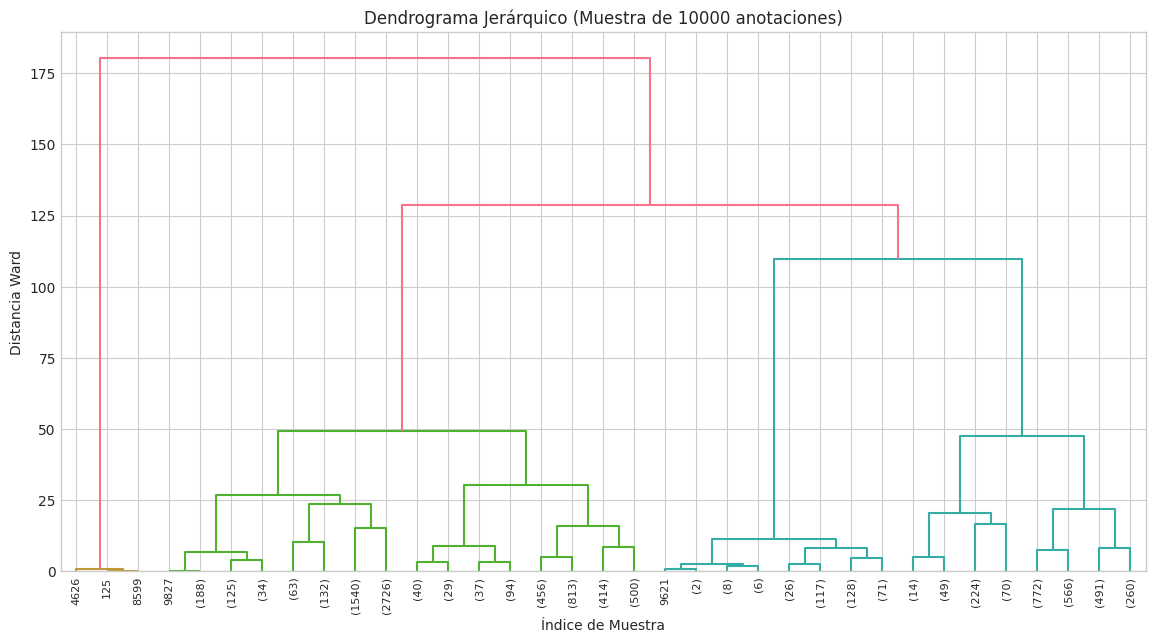

Calculando método del codo...
✓ Gráfico guardado: ../reports/eda/elbow_method.png


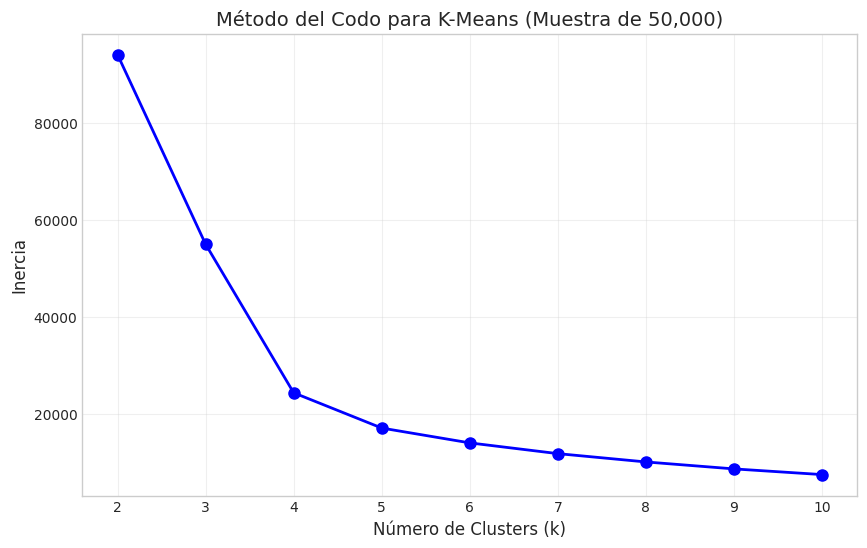


Aplicando Mini-Batch K-Means con k=4...

Distribución de tipos por cluster:
type_entity  COLOR     FOOD  PART  PHYSICAL_QUALITY  PROCESS  PURPOSE  \
cluster                                                                 
0                3  3149518     0                 0        0        0   
1                0  1258428     0                 0        0        0   
2                0   392726    25               294      486       56   
3               77  6114044     0                 0        0        0   

type_entity  QUANTITY  TASTE  UNIT  
cluster                             
0                   0      0     0  
1                   0      0     0  
2                1466     44  1263  
3                   0      0     0  

Estadísticas por cluster:
        entity_length_chars                    type_entity
                       mean       std min  max       count
cluster                                                   
0                 10.467825  1.705581   8   15     3149521

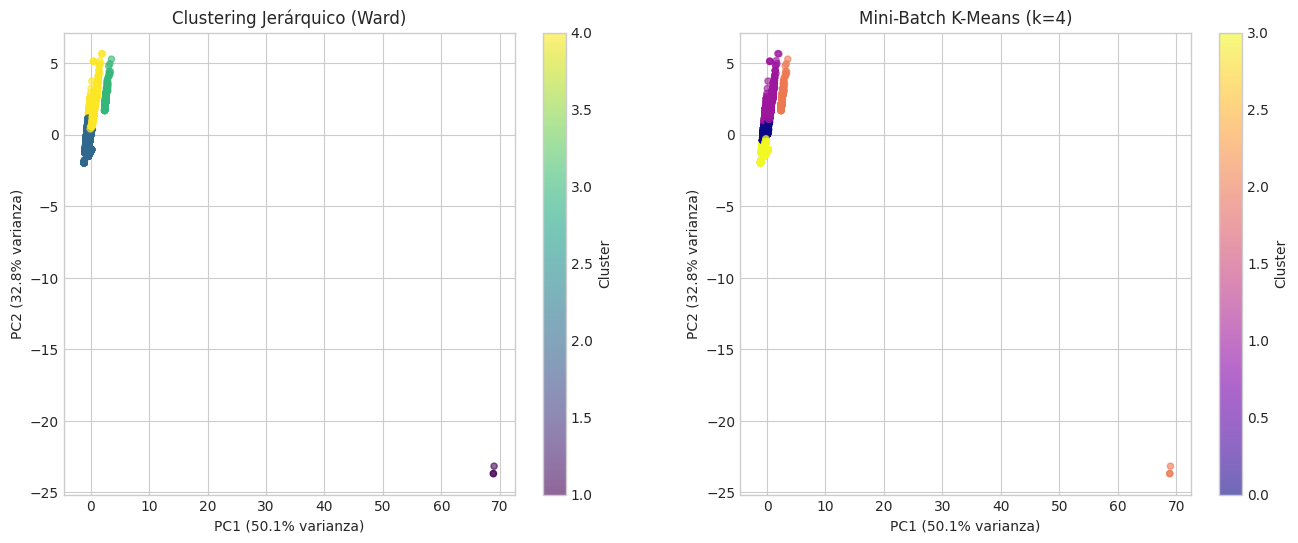

✓ Reporte guardado: ../reports/eda/clustering_report.json


In [14]:
# =============================================================================
# SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
# =============================================================================
print_section("SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN")
liberar_ram()

clustering_report = {}

# Preparación de datos para clustering
print("Preparando datos para clustering...")
df_cluster_full = main_with_entities.select([
    "entity_length_chars", "type_entity", "iob_tag"
]).to_pandas()

# Encode categóricas
le_type = LabelEncoder().fit(df_cluster_full["type_entity"])
le_iob = LabelEncoder().fit(df_cluster_full["iob_tag"])
df_cluster_full["type_encoded"] = le_type.transform(df_cluster_full["type_entity"])
df_cluster_full["iob_encoded"] = le_iob.transform(df_cluster_full["iob_tag"])

features_full = df_cluster_full[["entity_length_chars", "type_encoded", "iob_encoded"]].values
scaler = StandardScaler()
features_scaled_full = scaler.fit_transform(features_full)

# Muestreo estratificado para dendrograma
sample_size = 10000
df_sample = main_with_entities.sample(n=min(sample_size, len(main_with_entities)), seed=42).to_pandas()
df_sample["type_encoded"] = le_type.transform(df_sample["type_entity"])
df_sample["iob_encoded"] = le_iob.transform(df_sample["iob_tag"])
features_sample = df_sample[["entity_length_chars", "type_encoded", "iob_encoded"]].values
features_scaled_sample = scaler.transform(features_sample)

# Dendrograma jerárquico
print("Generando dendrograma...")
Z = linkage(features_scaled_sample, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, ax=ax)
ax.set_title(f"Dendrograma Jerárquico (Muestra de {len(df_sample)} anotaciones)")
ax.set_xlabel("Índice de Muestra")
ax.set_ylabel("Distancia Ward")
plot_and_save(fig, 'dendrogram.png')

# Método del codo
print("Calculando método del codo...")
elbow_sample_size = min(50000, len(features_scaled_full))
elbow_indices = np.random.choice(len(features_scaled_full), elbow_sample_size, replace=False)
features_elbow = features_scaled_full[elbow_indices]

inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_elbow)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title(f'Método del Codo para K-Means (Muestra de {elbow_sample_size:,})', fontsize=14)
ax.grid(True, alpha=0.3)
plot_and_save(fig, 'elbow_method.png')

# K-Means óptimo (asumimos k=4 basado en elbow, ajusta según visualización)
k_opt = 4
print(f"\nAplicando Mini-Batch K-Means con k={k_opt}...")
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled_full)
df_cluster_full['cluster'] = mb_kmeans.labels_

# Análisis de clusters
cluster_summary = df_cluster_full.groupby(['cluster', 'type_entity']).size().unstack(fill_value=0)
print("\nDistribución de tipos por cluster:")
print(cluster_summary)

cluster_means = df_cluster_full.groupby('cluster').agg({
    'entity_length_chars': ['mean', 'std', 'min', 'max'],
    'type_entity': 'count'
})
print("\nEstadísticas por cluster:")
print(cluster_means)

clustering_report['optimal_k'] = k_opt
clustering_report['inertias'] = {int(k): float(inertia) for k, inertia in zip(K_range, inertias)}

# PCA para visualización
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters jerárquicos
num_clusters_hier = 4
clusters_hier = fcluster(Z, t=num_clusters_hier, criterion='maxclust')
scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=clusters_hier, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].set_title('Clustering Jerárquico (Ward)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: K-Means en muestra
df_sample['cluster_kmeans'] = mb_kmeans.predict(features_scaled_sample)
scatter2 = axes[1].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=df_sample['cluster_kmeans'], cmap='plasma', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].set_title(f'Mini-Batch K-Means (k={k_opt})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plot_and_save(fig, 'clustering_pca.png')

save_report(clustering_report, 'clustering_report.json')


SECCIÓN 8: ANÁLISIS DE CORRELACIONES
RAM liberada: 0.00 MB
RAM actual: 17960.83 MB
✓ Gráfico guardado: ../reports/eda/correlation_matrix.png


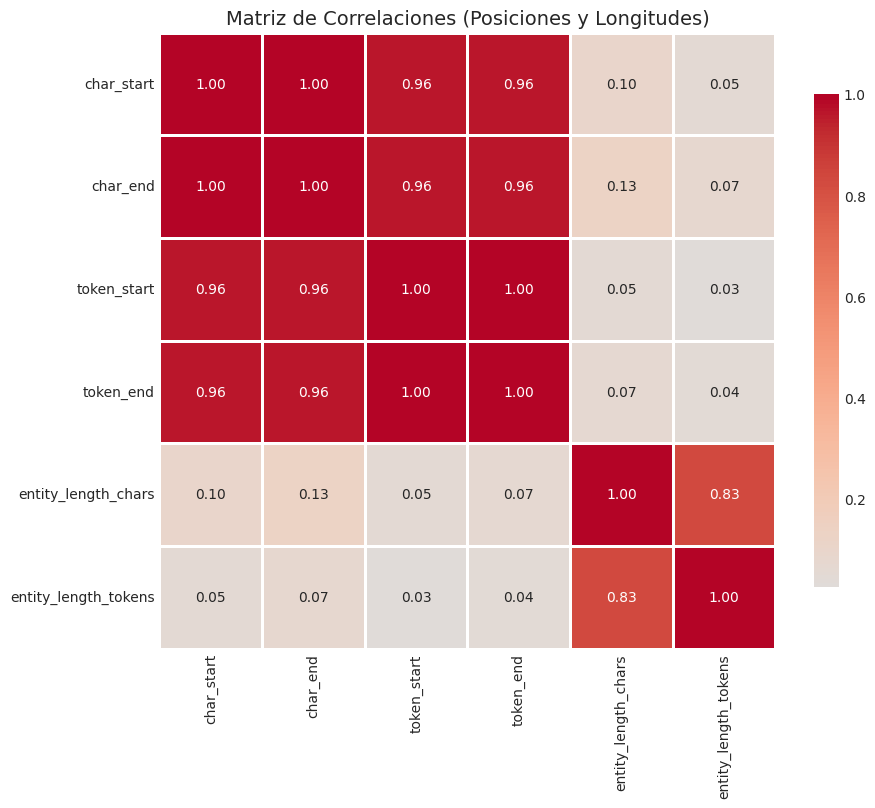


Correlaciones más fuertes (|r| > 0.5, excluyendo diagonales):
  token_start <-> token_end: 1.000
  char_start <-> char_end: 1.000
  char_start <-> token_end: 0.962
  char_start <-> token_start: 0.962
  char_end <-> token_end: 0.961
  char_end <-> token_start: 0.960
  entity_length_chars <-> entity_length_tokens: 0.834


In [11]:
# =============================================================================
# SECCIÓN 8: ANÁLISIS DE CORRELACIONES
# =============================================================================
print_section("SECCIÓN 8: ANÁLISIS DE CORRELACIONES")
liberar_ram()

# Correlaciones numéricas
corr_cols = ["char_start", "char_end", "token_start", "token_end", 
             "entity_length_chars", "entity_length_tokens"]
corr_df = main_with_entities.select(corr_cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de Correlaciones (Posiciones y Longitudes)", fontsize=14)
plot_and_save(fig, 'correlation_matrix.png')

# Correlaciones destacables
print("\nCorrelaciones más fuertes (|r| > 0.5, excluyendo diagonales):")
corr_pairs = []
for i in range(len(corr_df.columns)):
    for j in range(i+1, len(corr_df.columns)):
        corr_val = corr_df.iloc[i, j]
        if abs(corr_val) > 0.5:
            corr_pairs.append({
                'var1': corr_df.columns[i],
                'var2': corr_df.columns[j],
                'correlation': corr_val
            })

for pair in sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
    print(f"  {pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")

In [12]:
# =============================================================================
# SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS
# =============================================================================
print_section("SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS")

entity_analysis = {}

# Top entidades más frecuentes
print("\n--- Top 20 Entidades Más Frecuentes ---")
entity_freq = main_with_entities.group_by("entity").agg([
    pl.count().alias("frequency"),
    pl.col("type_entity").first().alias("type")
]).sort("frequency", descending=True)

print(entity_freq.head(20))

# Entidades que aparecen con un solo tipo vs múltiples
entity_type_variety = main_with_entities.group_by("entity").agg([
    pl.col("type_entity").n_unique().alias("num_types"),
    pl.count().alias("total_occurrences")
])

single_type = entity_type_variety.filter(pl.col("num_types") == 1)
multi_type = entity_type_variety.filter(pl.col("num_types") > 1)

print(f"\nEntidades con tipo único: {len(single_type)} ({100*len(single_type)/len(entity_type_variety):.1f}%)")
print(f"Entidades con múltiples tipos: {len(multi_type)} ({100*len(multi_type)/len(entity_type_variety):.1f}%)")

entity_analysis['single_type_entities'] = len(single_type)
entity_analysis['multi_type_entities'] = len(multi_type)

# Análisis de capitalización por tipo
caps_by_type = main_with_entities.group_by("type_entity").agg([
    pl.col("is_all_caps").mean().alias("pct_all_caps"),
    pl.col("is_capitalized").mean().alias("pct_capitalized"),
    pl.col("has_numbers").mean().alias("pct_with_numbers")
]).sort("pct_all_caps", descending=True)

print("\nCaracterísticas textuales por tipo (top 10):")
print(caps_by_type.head(10))

# Tokens más comunes en entidades (análisis básico de palabras)
print("\n--- Análisis de Tokens en Entidades ---")
all_tokens = main_with_entities["entity"].str.split(" ").explode().str.to_lowercase()
token_freq = all_tokens.value_counts().head(30)
print("Top 30 tokens más frecuentes en entidades:")
print(token_freq)

save_report(entity_analysis, 'entity_analysis.json')


SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS

--- Top 20 Entidades Más Frecuentes ---
shape: (20, 3)
┌───────────────┬───────────┬──────┐
│ entity        ┆ frequency ┆ type │
│ ---           ┆ ---       ┆ ---  │
│ str           ┆ u32       ┆ str  │
╞═══════════════╪═══════════╪══════╡
│ salt          ┆ 554832    ┆ FOOD │
│ sugar         ┆ 391535    ┆ FOOD │
│ butter        ┆ 325092    ┆ FOOD │
│ flour         ┆ 297237    ┆ FOOD │
│ eggs          ┆ 255038    ┆ FOOD │
│ …             ┆ …         ┆ …    │
│ brown sugar   ┆ 90853     ┆ FOOD │
│ baking powder ┆ 86187     ┆ FOOD │
│ oil           ┆ 83808     ┆ FOOD │
│ margarine     ┆ 81808     ┆ FOOD │
│ cheese        ┆ 79473     ┆ FOOD │
└───────────────┴───────────┴──────┘

Entidades con tipo único: 131014 (99.8%)
Entidades con múltiples tipos: 207 (0.2%)

Características textuales por tipo (top 10):
shape: (9, 4)
┌──────────────────┬──────────────┬─────────────────┬──────────────────┐
│ type_entity      ┆ pct_all_caps ┆ pct_capitalized 

In [13]:
# =============================================================================
# SECCIÓN 10: CASOS EXTREMOS Y MUESTRAS PARA REVISIÓN MANUAL
# =============================================================================
print_section("SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL")

extreme_cases = {}

# 1. Entidades más largas
print("\n--- Top 15 Entidades Más Largas ---")
longest_entities = main_with_entities.sort("entity_length_chars", descending=True).head(15).select([
    "sentence_id", "entity", "type_entity", "entity_length_chars", "iob_tag"
])
print(longest_entities)
save_report(longest_entities.to_pandas(), 'longest_entities.csv', 'csv')

# 2. Entidades más cortas (posibles errores)
print("\n--- Entidades Más Cortas (1 char) ---")
shortest_entities = main_with_entities.filter(pl.col("entity_length_chars") == 1).head(20).select([
    "sentence_id", "entity", "type_entity"
])
print(shortest_entities)
extreme_cases['single_char_entities'] = len(main_with_entities.filter(pl.col("entity_length_chars") == 1))

# 3. Oraciones con más entidades
print("\n--- Top 10 Oraciones Con Más Entidades ---")
most_annotated = sentences_with_annots.sort("num_entities", descending=True).head(10).select([
    "sentence_id", "num_entities", "sentence_length_chars", "num_tokens"
])
print(most_annotated)

# Obtener texto de estas oraciones para inspección
if len(most_annotated) > 0:
    top_sent_ids = most_annotated["sentence_id"].to_list()
    top_sentences_full = sentences_df.filter(pl.col("sentence_id").is_in(top_sent_ids)).select([
        "sentence_id", "sentence"
    ]).join(most_annotated, on="sentence_id")
    
    print("\nTexto completo de las 5 oraciones con más entidades:")
    for row in top_sentences_full.head(5).iter_rows(named=True):
        print(f"\nSentence ID: {row['sentence_id']} ({row['num_entities']} entidades)")
        print(f"Texto: {row['sentence'][:200]}..." if len(row['sentence']) > 200 else f"Texto: {row['sentence']}")

# 4. Entidades con caracteres especiales inusuales
print("\n--- Entidades con Caracteres Especiales ---")
special_char_entities = main_with_entities.filter(
    pl.col("entity").str.contains(r"[^\w\s\-']")  # No alfanumérico, espacio, guión o apóstrofo
).head(20).select(["entity", "type_entity"])
print(special_char_entities)
extreme_cases['entities_with_special_chars'] = len(main_with_entities.filter(
    pl.col("entity").str.contains(r"[^\w\s\-']")
))

# 5. Entidades numéricas puras
print("\n--- Entidades Numéricas Puras ---")
numeric_entities = main_with_entities.filter(
    pl.col("entity").str.contains(r"^\d+$")
).head(20).select(["entity", "type_entity"])
print(numeric_entities)
extreme_cases['pure_numeric_entities'] = len(main_with_entities.filter(
    pl.col("entity").str.contains(r"^\d+$")
))

save_report(extreme_cases, 'extreme_cases.json')


SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL

--- Top 15 Entidades Más Largas ---
shape: (15, 5)
┌──────────────┬───────────────────────┬─────────────┬─────────────────────┬───────────────────────┐
│ sentence_id  ┆ entity                ┆ type_entity ┆ entity_length_chars ┆ iob_tag               │
│ ---          ┆ ---                   ┆ ---         ┆ ---                 ┆ ---                   │
│ str          ┆ str                   ┆ str         ┆ i64                 ┆ str                   │
╞══════════════╪═══════════════════════╪═════════════╪═════════════════════╪═══════════════════════╡
│ SENT_2532180 ┆ http://www.foodnetwor ┆ FOOD        ┆ 135                 ┆                       │
│              ┆ k.com/rec…            ┆             ┆                     ┆                       │
│ SENT_1969507 ┆ http://www.foodnetwor ┆ FOOD        ┆ 132                 ┆                       │
│              ┆ k.com/rec…            ┆             ┆                     ┆               


SECCIÓN 11: RESUMEN EJECUTIVO

RESUMEN EJECUTIVO
{
  "dataset_overview": {
    "total_annotations": 10918430,
    "unique_entities": 417115,
    "annotated_sentences": 3178926,
    "total_sentences": 3178926,
    "coverage_pct": 100.0,
    "num_entity_types": 9
  },
  "quality_metrics": {
    "null_counts": {
      "entity_local_id": 0,
      "sentence_id": 0,
      "entity_id": 0,
      "char_start": 0,
      "char_end": 0,
      "token_start": 0,
      "token_end": 0,
      "entity": 0,
      "type_entity": 0,
      "iob_tag": 0,
      "entity_length_chars": 0,
      "entity_length_tokens": 0
    },
    "duplicates": 172681,
    "ambiguous_entities": 329,
    "overlaps": 156922,
    "invalid_positions": 0,
    "invalid_lengths": 431090
  },
  "imbalance_metrics": {
    "gini_coefficient": 0.8887287111995243,
    "entropy": 0.0035440007423797916,
    "max_min_ratio": 436588.64
  },
  "top_5_types": [
    {
      "type_entity": "FOOD",
      "count": 10914716
    },
    {
      "type_

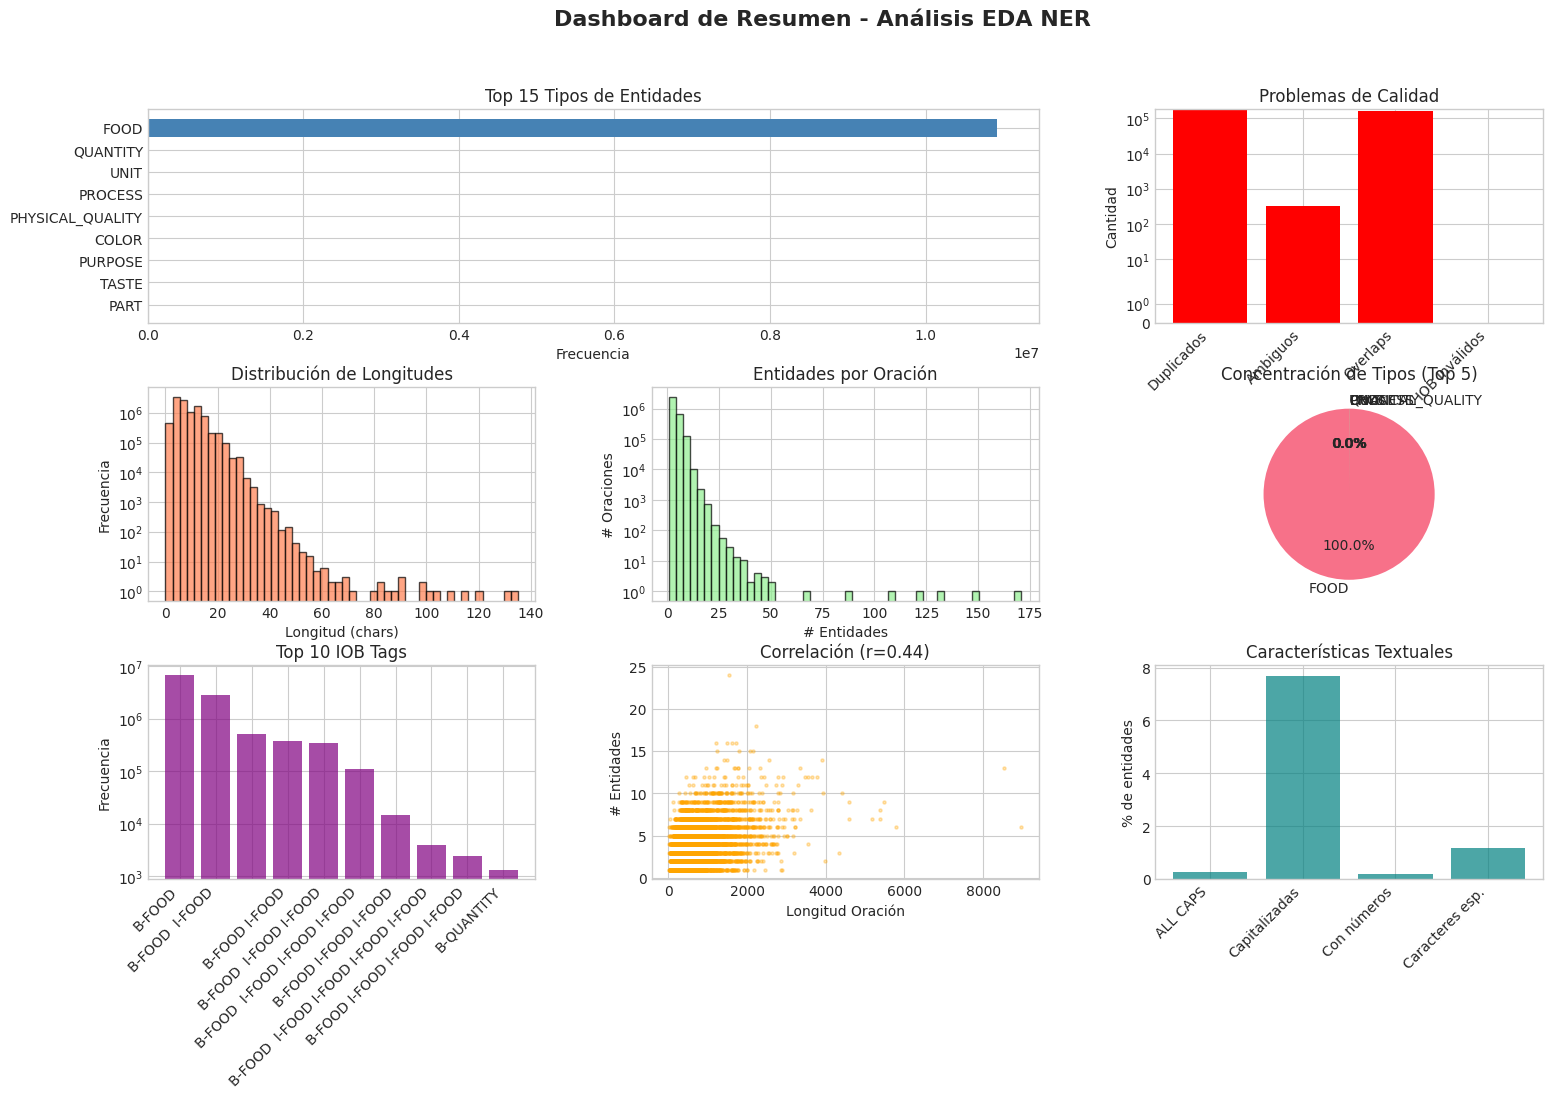

In [15]:
# =============================================================================
# SECCIÓN 11: RESUMEN EJECUTIVO Y EXPORTACIÓN FINAL
# =============================================================================
print_section("SECCIÓN 11: RESUMEN EJECUTIVO")

executive_summary = {
    "dataset_overview": {
        "total_annotations": total_annots,
        "unique_entities": unique_entities,
        "annotated_sentences": unique_sentences,
        "total_sentences": total_sentences,
        "coverage_pct": float(coverage),
        "num_entity_types": len(type_dist)
    },
    "quality_metrics": quality_report,
    "imbalance_metrics": {
        "gini_coefficient": float(gini),
        "entropy": float(ent),
        "max_min_ratio": float(max_ratio)
    },
    "top_5_types": type_dist.head(5).to_pandas().to_dict('records'),
    "length_statistics": {
        "mean_entity_length": float(main_with_entities["entity_length_chars"].mean()),
        "median_entity_length": float(main_with_entities["entity_length_chars"].median()),
        "max_entity_length": int(main_with_entities["entity_length_chars"].max()),
        "mean_sentence_length": float(sentences_df["sentence_length_chars"].mean())
    },
    "iob_validation": iob_report,
    "clustering": {
        "optimal_clusters": k_opt,
        "pca_variance_explained": float(pca.explained_variance_ratio_.sum())
    },
    "extreme_cases": extreme_cases,
    "recommendations": [
        "Revisar anotaciones duplicadas" if quality_report.get('duplicates', 0) > 0 else "✓ No hay duplicados",
        "Resolver entidades ambiguas con múltiples tipos" if quality_report.get('ambiguous_entities', 0) > 0 else "✓ No hay ambigüedades",
        "Corregir overlaps de anotaciones" if quality_report.get('overlaps', 0) > 0 else "✓ No hay overlaps",
        "Validar secuencias IOB inválidas" if iob_report.get('invalid_sequences', 0) > 0 else "✓ Secuencias IOB válidas",
        f"Considerar estratificación por tipo (Gini={gini:.2f})" if gini > 0.6 else "✓ Balance aceptable de tipos",
        "Revisar entidades de 1 carácter" if extreme_cases.get('single_char_entities', 0) > 100 else "✓ Pocas entidades de 1 char"
    ]
}

print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
print(json.dumps(executive_summary, indent=2, ensure_ascii=False))

save_report(executive_summary, 'executive_summary.json')

# Gráfico de resumen final
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribución de tipos (barras horizontales, top 15)
ax1 = fig.add_subplot(gs[0, :2])
top15_dist = type_dist.head(15).to_pandas()

# Eliminar filas donde type_entity es None o NaN para evitar errores en el gráfico
top15_dist = top15_dist[top15_dist["type_entity"].notnull()]

# Convertir type_entity a string explícitamente (por si acaso)
top15_dist["type_entity"] = top15_dist["type_entity"].astype(str)

ax1.barh(top15_dist["type_entity"], top15_dist["count"], color='steelblue')
ax1.set_xlabel("Frecuencia")
ax1.set_title("Top 15 Tipos de Entidades")
ax1.invert_yaxis()

# 2. Métricas de calidad
ax2 = fig.add_subplot(gs[0, 2])
quality_metrics = [
    quality_report.get('duplicates', 0),
    quality_report.get('ambiguous_entities', 0),
    quality_report.get('overlaps', 0),
    iob_report.get('invalid_sequences', 0)
]
quality_labels = ['Duplicados', 'Ambiguos', 'Overlaps', 'IOB Inválidos']
colors_quality = ['red' if m > 0 else 'green' for m in quality_metrics]
ax2.bar(range(len(quality_metrics)), quality_metrics, color=colors_quality)
ax2.set_xticks(range(len(quality_labels)))
ax2.set_xticklabels(quality_labels, rotation=45, ha='right')
ax2.set_ylabel("Cantidad")
ax2.set_title("Problemas de Calidad")
ax2.set_yscale('symlog')

# 3. Distribución de longitudes
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(main_with_entities["entity_length_chars"].to_numpy(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel("Longitud (chars)")
ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de Longitudes")
ax3.set_yscale('log')

# 4. Entidades por oración
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sentences_with_annots["num_entities"].to_numpy(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel("# Entidades")
ax4.set_ylabel("# Oraciones")
ax4.set_title("Entidades por Oración")
ax4.set_yscale('log')

# 5. Desbalance (pie chart)
ax5 = fig.add_subplot(gs[1, 2])
top5_counts = type_dist.head(5)["count"].to_numpy()
others = type_dist["count"].sum() - top5_counts.sum()
pie_data = list(top5_counts) + [others]
pie_labels = type_dist.head(5)["type_entity"].to_list() + ['Otros']
ax5.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax5.set_title("Concentración de Tipos (Top 5)")

# 6. IOB distribution
ax6 = fig.add_subplot(gs[2, 0])
iob_top = iob_dist.head(10).to_pandas()
ax6.bar(range(len(iob_top)), iob_top["count"], color='purple', alpha=0.7)
ax6.set_xticks(range(len(iob_top)))
ax6.set_xticklabels(iob_top["iob_tag"], rotation=45, ha='right')
ax6.set_ylabel("Frecuencia")
ax6.set_title("Top 10 IOB Tags")
ax6.set_yscale('log')

# 7. Correlación longitud-entidades
ax7 = fig.add_subplot(gs[2, 1])
scatter_sample = sentences_with_annots.sample(n=min(10000, len(sentences_with_annots)), seed=42).to_pandas()
ax7.scatter(scatter_sample["sentence_length_chars"], scatter_sample["num_entities"], 
            alpha=0.3, s=5, color='orange')
ax7.set_xlabel("Longitud Oración")
ax7.set_ylabel("# Entidades")
ax7.set_title(f"Correlación (r={corr_length_annots:.2f})")

# 8. Características textuales
ax8 = fig.add_subplot(gs[2, 2])
char_features_pct = [
    100 * caps_stats["all_caps"][0] / total_annots,
    100 * caps_stats["capitalized"][0] / total_annots,
    100 * caps_stats["with_numbers"][0] / total_annots,
    100 * caps_stats["with_special_chars"][0] / total_annots
]
char_labels = ['ALL CAPS', 'Capitalizadas', 'Con números', 'Caracteres esp.']
ax8.bar(range(len(char_features_pct)), char_features_pct, color='teal', alpha=0.7)
ax8.set_xticks(range(len(char_labels)))
ax8.set_xticklabels(char_labels, rotation=45, ha='right')
ax8.set_ylabel("% de entidades")
ax8.set_title("Características Textuales")

fig.suptitle("Dashboard de Resumen - Análisis EDA NER", fontsize=16, fontweight='bold')
plot_and_save(fig, 'executive_dashboard.png')


In [ ]:
# =============================================================================
# FINALIZACIÓN
# =============================================================================
print("\n" + "="*80)
print("✓ EDA COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"\nReportes generados en: {REPORT_DIR}")
print("\nArchivos creados:")
for report_file in sorted(REPORT_DIR.glob("*")):
    print(f"  - {report_file.name}")

print("\n" + "="*80)
print("RECOMENDACIONES FINALES:")
print("="*80)
for i, rec in enumerate(executive_summary['recommendations'], 1):
    print(f"{i}. {rec}")

print("\n¡Análisis completado! Revisa los reportes y visualizaciones generadas.")
print("="*80)


✓ EDA COMPLETADO EXITOSAMENTE

Reportes generados en: ../reports/eda

Archivos creados:
  - ambiguous_entities.csv
  - basic_stats.json
  - clustering_pca.png
  - clustering_report.json
  - cooccurrence_report.json
  - cooccurrences.csv
  - correlation_matrix.png
  - dendrogram.png
  - elbow_method.png
  - entity_analysis.json
  - executive_dashboard.png
  - executive_summary.json
  - extreme_cases.json
  - iob_validation_report.json
  - longest_entities.csv
  - quality_report.json
  - text_analysis.json
  - text_analysis.png
  - type_distribution.png
  - type_stats.json

RECOMENDACIONES FINALES:
1. Revisar anotaciones duplicadas
2. Resolver entidades ambiguas con múltiples tipos
3. Corregir overlaps de anotaciones
4. ✓ Secuencias IOB válidas
5. Considerar estratificación por tipo (Gini=0.89)
6. Revisar entidades de 1 carácter

¡Análisis completado! Revisa los reportes y visualizaciones generadas.


: 